In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/cip_ppi_unrate_weather_cleaned_data.csv")

In [ ]:
df = pd.read_csv("/content/EDA_5_30.csv")
df['searchDate'] = pd.to_datetime(df['searchDate'])
search_dates = df['searchDate'].sort_values().unique()
print("검색 날짜 수 : ", len(search_dates))
print("시작 날짜 : ", search_dates[0])
print("끝 날짜 : ", search_dates[-1])

검색 날짜 수 :  171
시작 날짜 :  2022-04-16 00:00:00
끝 날짜 :  2022-10-05 00:00:00


In [ ]:
import pandas as pd

# 1) CSV 불러오기: Date 컬럼을 datetime 파싱하고 인덱스로 지정
oil = pd.read_csv(
    "/content/Oil (WTI)_11_18_22-04_14_22.csv",
    parse_dates=["Date"],
    index_col="Date",
    infer_datetime_format=True
)

# 2) 인덱스 중복 제거 – 중복된 날짜가 있으면 가장 마지막 행만 남기기
oil = oil[~oil.index.duplicated(keep="last")]

# 3) 최소–최대 날짜 사이의 모든 일자를 가지는 인덱스 생성
full_idx = pd.date_range(start=oil.index.min(), end=oil.index.max(), freq="D")

# 4) reindex → 빈 날짜는 NaN
oil = oil.reindex(full_idx)

# 5) 바로 이전(가장 최근) 값으로 채우기
oil = oil.ffill()

# 6) 인덱스 이름(Date) 복원 (선택)
oil.index.name = "Date"

print(oil.head(10))
print(oil.tail(10))




              Open   Close    High     Low  Volume
Date                                              
2022-04-14  104.14  106.95  107.64  102.13     NaN
2022-04-15  104.14  106.95  107.64  102.13     NaN
2022-04-16  104.14  106.95  107.64  102.13     NaN
2022-04-17  104.14  106.95  107.64  102.13     NaN
2022-04-18  106.83  108.21  109.79  106.00     NaN
2022-04-19  107.84  102.56  108.87  102.08     NaN
2022-04-20    0.00  102.19  103.96   99.88     NaN
2022-04-21  102.66  103.79  105.42  102.00     NaN
2022-04-22  103.95  102.07  104.20  101.06     NaN
2022-04-23  103.95  102.07  104.20  101.06     NaN
             Open  Close   High    Low  Volume
Date                                          
2022-11-09  88.70  85.83  89.22  85.50     NaN
2022-11-10  85.74  86.47  87.34  84.69     NaN
2022-11-11  86.37  88.96  90.10  86.19     NaN
2022-11-12  86.37  88.96  90.10  86.19     NaN
2022-11-13  86.37  88.96  90.10  86.19     NaN
2022-11-14  88.96  85.87  89.84  85.16     NaN
2022-11-15  

<ipython-input-28-11a9dbb8a2bb>:4: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  oil = pd.read_csv(
<ipython-input-28-11a9dbb8a2bb>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil = pd.read_csv(


In [ ]:
oil.drop(['Volume'], axis=1, inplace=True)
print(oil.head(10))
print(oil.tail(10))
oil.describe()

              Open   Close    High     Low
Date                                      
2022-04-14  104.14  106.95  107.64  102.13
2022-04-15  104.14  106.95  107.64  102.13
2022-04-16  104.14  106.95  107.64  102.13
2022-04-17  104.14  106.95  107.64  102.13
2022-04-18  106.83  108.21  109.79  106.00
2022-04-19  107.84  102.56  108.87  102.08
2022-04-20    0.00  102.19  103.96   99.88
2022-04-21  102.66  103.79  105.42  102.00
2022-04-22  103.95  102.07  104.20  101.06
2022-04-23  103.95  102.07  104.20  101.06
             Open  Close   High    Low
Date                                  
2022-11-09  88.70  85.83  89.22  85.50
2022-11-10  85.74  86.47  87.34  84.69
2022-11-11  86.37  88.96  90.10  86.19
2022-11-12  86.37  88.96  90.10  86.19
2022-11-13  86.37  88.96  90.10  86.19
2022-11-14  88.96  85.87  89.84  85.16
2022-11-15  85.21  86.92  88.67  84.07
2022-11-16  86.70  85.59  87.51  84.18
2022-11-17  84.65  81.64  85.57  81.40
2022-11-18  82.04  80.11  82.61  77.26


,Open,Close,High,Low
count,219.000000,219.000000,219.000000,219.000000
mean,94.130000,97.327352,99.487352,93.594247
std,20.527143,11.476034,11.564765,15.589483
min,0.000000,76.710000,79.510000,0.000000
25%,87.040000,87.770000,89.700000,85.895000
50%,93.980000,94.700000,97.370000,92.290000
75%,105.380000,107.620000,109.340000,103.630000
max,122.510000,122.110000,123.680000,120.790000


In [ ]:
oil.drop(['Open', 'High', 'Low'], axis = 1, inplace = True)
oil.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 219 entries, 2022-04-14 to 2022-11-18
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   219 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB


In [ ]:
oil.tail(20)
oil = oil.drop(pd.date_range(start="2022-04-14", end="2022-04-15", freq="D"))


In [ ]:
oil = oil.drop(pd.date_range(start="2022-04-14", end="2022-04-15", freq="D"))

In [ ]:
oil.rename({'Close': 'oil_price'}, axis=1, inplace=True)
oil.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 217 entries, 2022-04-16 to 2022-11-18
Freq: D
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   oil_price  217 non-null    float64
dtypes: float64(1)
memory usage: 3.4 KB


In [ ]:
oil.describe()

,oil_price
count,217.000000
mean,97.238664
std,11.491455
min,76.710000
25%,87.760000
50%,94.700000
75%,107.620000
max,122.110000


In [ ]:
oil.to_csv("/content/Oil.csv")

In [ ]:
import pandas as pd

# 1) CSV 불러오기: 날짜 칼럼 파싱
cleaned = pd.read_csv(
    "/content/EDA_5_30.csv",
    parse_dates=["searchDate"]  # cleaned_data.csv 안의 날짜 칼럼 이름
)

oil = pd.read_csv(
    "/content/Oil.csv",
    parse_dates=["Date"]          # oil.csv 안의 날짜 칼럼 이름
)

# 2) oil DataFrame에 Date 칼럼을 인덱스로 쓰셨다면, reset_index() 해서 칼럼으로 복원해 주세요.

if oil.index.name == "Date":
    oil = oil.reset_index()

# 3) 내부 조인 (cleaned의 search date ↔ oil의 Date)
merged = pd.merge(
    cleaned,
    oil,
    left_on="searchDate",
    right_on="Date",
    how="inner"
)

# 4) (선택) 중복된 Date 칼럼 제거
merged = merged.drop(columns=["Date"])

# 5) 결과 저장
merged.to_csv("/content/oil_final.csv", index=False)


In [ ]:
final = pd.read_csv("/content/oil_final.csv")
final.describe()


,baseFare,totalFare,seatsRemaining,totalTravelDistance,cpi,ppi,unemployment_rate,travelDurationMinutes,start_temp,start_feelslike,...,hour_6~12,hour_12~18,hour_18~24,days_before_departure,flightMonth,cabin_score,stop_count,fare_per_minute,event_day,oil_price
count,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,...,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000
mean,292.646494,340.379102,5.976280,1623.864965,294.302701,271.718943,3.568754,427.568166,21.794457,22.080104,...,0.467613,0.315180,0.171289,26.903675,7.803679,1.003402,0.827633,0.831374,0.095459,99.094005
std,182.784410,195.567221,2.881062,847.687940,2.339595,4.547135,0.061321,224.164349,5.516577,6.219559,...,0.498950,0.464588,0.376762,16.324063,1.647625,0.083397,0.584060,0.612327,0.293848,11.297857
min,0.010000,19.590000,0.000000,0.000000,288.582000,265.061000,3.500000,1.000000,-10.600000,-14.700000,...,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,0.000000,0.000015,0.000000,76.710000
25%,159.530000,197.200000,4.000000,913.000000,294.940000,267.898000,3.500000,261.000000,17.900000,17.900000,...,0.000000,0.000000,0.000000,13.000000,7.000000,1.000000,0.000000,0.446333,0.000000,89.550000
50%,260.480000,305.610000,7.000000,1487.000000,295.072000,272.274000,3.600000,408.000000,22.400000,22.400000,...,0.000000,0.000000,0.000000,26.000000,8.000000,1.000000,1.000000,0.698101,0.000000,98.620000
75%,398.140000,452.200000,9.000000,2398.000000,295.162000,273.251000,3.600000,565.000000,25.900000,26.300000,...,1.000000,1.000000,0.000000,40.000000,9.000000,1.000000,1.000000,1.052240,0.000000,107.990000
max,4557.210000,4913.600000,10.000000,7504.000000,297.979000,280.251000,3.700000,1439.000000,34.900000,36.700000,...,1.000000,1.000000,1.000000,60.000000,11.000000,4.000000,4.000000,19.212574,1.000000,122.110000


In [ ]:
final.isnull().sum()

,0
searchDate,0
flightDate,0
startingAirport,0
destinationAirport,0
travelDuration,0
...,...
cabin_score,0
stop_count,0
fare_per_minute,0
event_day,0


In [ ]:
oil.isnull().sum()

,0
Date,0
Close,0


In [ ]:
final.isnull().sum()

,0
searchDate,0
flightDate,0
startingAirport,0
destinationAirport,0
travelDuration,0
...,...
stop_count,1
fare_per_minute,1
event_day,1
Date,0


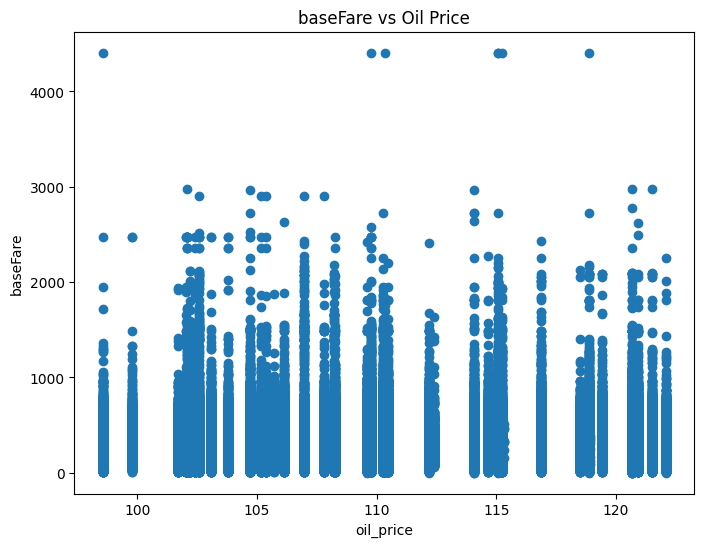

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(final['oil_price'],final['baseFare'])
plt.xlabel('oil_price')
plt.ylabel('baseFare')
plt.title('baseFare vs Oil Price')
plt.show()

In [ ]:
final.describe()

,baseFare,totalFare,seatsRemaining,totalTravelDistance,cpi,ppi,unemployment_rate,travelDurationMinutes,start_temp,start_feelslike,...,hour_6~12,hour_12~18,hour_18~24,days_before_departure,flightMonth,cabin_score,stop_count,fare_per_minute,event_day,oil_price
count,240016.000000,240016.000000,240016.000000,240016.000000,240015.000000,240015.000000,240015.000000,240015.000000,240015.000000,240015.000000,...,240015.000000,240015.000000,240015.000000,240015.000000,240015.000000,240015.000000,240015.000000,240015.000000,240015.000000,240016.000000
mean,334.456998,385.619572,5.608322,1584.531265,291.377417,272.596520,3.627583,417.135900,21.921959,22.188297,...,0.457509,0.316697,0.177935,27.367660,5.844985,1.006143,0.783389,0.968618,0.091094,110.132855
std,198.227325,211.704387,2.967721,833.615626,2.270152,5.264694,0.044693,221.831425,5.288347,5.931198,...,0.498192,0.465189,0.382459,17.266629,0.843032,0.110793,0.575383,0.653117,0.287744,6.469959
min,2.000000,23.970000,0.000000,0.000000,288.582000,265.310000,3.600000,8.000000,1.700000,-1.700000,...,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,0.000000,0.003030,0.000000,98.540000
25%,189.770000,230.200000,3.000000,872.000000,288.582000,265.310000,3.600000,245.000000,18.200000,18.200000,...,0.000000,0.000000,0.000000,12.000000,5.000000,1.000000,0.000000,0.551353,0.000000,104.690000
50%,306.040000,354.680000,7.000000,1445.000000,291.299000,273.251000,3.600000,397.000000,22.000000,22.000000,...,0.000000,0.000000,0.000000,26.000000,6.000000,1.000000,1.000000,0.834749,0.000000,109.770000
75%,446.512500,504.600000,8.000000,2356.000000,291.299000,273.251000,3.700000,559.000000,26.000000,26.500000,...,1.000000,1.000000,0.000000,42.000000,6.000000,1.000000,1.000000,1.220193,0.000000,115.070000
max,4407.440000,4752.600000,10.000000,7504.000000,295.072000,280.251000,3.700000,1436.000000,34.900000,36.700000,...,1.000000,1.000000,1.000000,60.000000,8.000000,4.000000,3.000000,18.177882,1.000000,122.110000


In [ ]:
check = pd.read_csv("/content/EDA_5_30.csv")


In [ ]:
check.describe()

,baseFare,totalFare,seatsRemaining,totalTravelDistance,cpi,ppi,unemployment_rate,travelDurationMinutes,start_temp,start_feelslike,...,hour_0~6,hour_6~12,hour_12~18,hour_18~24,days_before_departure,flightMonth,cabin_score,stop_count,fare_per_minute,event_day
count,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,...,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000,821388.000000
mean,292.646494,340.379102,5.976280,1623.864965,294.302701,271.718943,3.568754,427.568166,21.794457,22.080104,...,0.045917,0.467613,0.315180,0.171289,26.903675,7.803679,1.003402,0.827633,0.831374,0.095459
std,182.784410,195.567221,2.881062,847.687940,2.339595,4.547135,0.061321,224.164349,5.516577,6.219559,...,0.209306,0.498950,0.464588,0.376762,16.324063,1.647625,0.083397,0.584060,0.612327,0.293848
min,0.010000,19.590000,0.000000,0.000000,288.582000,265.061000,3.500000,1.000000,-10.600000,-14.700000,...,0.000000,0.000000,0.000000,0.000000,1.000000,4.000000,1.000000,0.000000,0.000015,0.000000
25%,159.530000,197.200000,4.000000,913.000000,294.940000,267.898000,3.500000,261.000000,17.900000,17.900000,...,0.000000,0.000000,0.000000,0.000000,13.000000,7.000000,1.000000,0.000000,0.446333,0.000000
50%,260.480000,305.610000,7.000000,1487.000000,295.072000,272.274000,3.600000,408.000000,22.400000,22.400000,...,0.000000,0.000000,0.000000,0.000000,26.000000,8.000000,1.000000,1.000000,0.698101,0.000000
75%,398.140000,452.200000,9.000000,2398.000000,295.162000,273.251000,3.600000,565.000000,25.900000,26.300000,...,0.000000,1.000000,1.000000,0.000000,40.000000,9.000000,1.000000,1.000000,1.052240,0.000000
max,4557.210000,4913.600000,10.000000,7504.000000,297.979000,280.251000,3.700000,1439.000000,34.900000,36.700000,...,1.000000,1.000000,1.000000,1.000000,60.000000,11.000000,4.000000,4.000000,19.212574,1.000000
